In [ ]:
!rm -r test
!mkdir ./test
! unzip /content/drive/MyDrive/msds/test.zip -d ./test

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -r ./train
!mkdir ./train
! unzip /content/drive/MyDrive/msds/train.zip -d ./train

In [4]:
import pandas as pd
! unzip /content/drive/MyDrive/msds/train_labels.csv.zip -d ./
df_labels=pd.read_csv("train_labels.csv")
df_labels.head()

Archive:  /content/drive/MyDrive/msds/train_labels.csv.zip
  inflating: ./train_labels.csv      


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [5]:
df_labels.id = df_labels.id + '.tif'
df_labels.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835.tif,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77.tif,1
2,755db6279dae599ebb4d39a9123cce439965282d.tif,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08.tif,0
4,068aba587a4950175d04c680d38943fd488d6a9d.tif,0


In [6]:
!touch t
!ls train >  t

In [7]:
l=[]
with open("t","r") as f:
  l=f.readlines()
for i in range(len(l)):
  l[i]=l[i].replace('\n','')


In [8]:
#df_labels.reset_index(inplace=True)
train=df_labels[df_labels.id.isin(l)]

In [9]:
!mkdir valid


In [35]:
!touch t2
!ls test > t2
l=[]
with open("t2","r") as f:
  l=f.readlines()
for i in range(len(l)):
  l[i]=l[i].replace('\n','')

In [37]:
df_labels.reset_index(inplace=True)
test=pd.DataFrame(l)
test

,0
0,00006537328c33e284c973d7b39d340809f7271b.tif
1,0000ec92553fda4ce39889f9226ace43cae3364e.tif
2,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2.tif
3,000253dfaa0be9d0d100283b22284ab2f6b643f6.tif
4,000270442cc15af719583a8172c87cd2bd9c7746.tif
...,...
57453,fffdd1cbb1ac0800f65309f344dd15e9331e1c53.tif
57454,fffdf4b82ba01f9cae88b9fa45be103344d9f6e3.tif
57455,fffec7da56b54258038b0d382b3d55010eceb9d7.tif
57456,ffff276d06a9e3fffc456f2a5a7a3fd1a2d322c6.tif


In [12]:
from sklearn.model_selection import train_test_split
train,valid = train_test_split(train, test_size=0.2)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.applications.resnet import ResNet152

In [14]:
from tensorflow.keras.models import Sequential
model = Sequential([
    ResNet152(),
    Dense(2,activation='softmax')
])
model.summary()

242900224/242900224 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet152 (Functional)      (None, 1000)              60419944  
                                                                 
 dense (Dense)               (None, 2)                 2002      
                                                                 
Total params: 60,421,946
Trainable params: 60,270,522
Non-trainable params: 151,424
_________________________________________________________________


In [27]:
optimizer = tf.keras.optimizers.RMSprop(0.001)
loss = tf.keras.losses.BinaryCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_gen = ImageDataGenerator(rescale=1/255)


In [17]:
!mkdir valid/0
!mkdir valid/1
!mkdir train/0
!mkdir train/1

In [18]:
d=train['id'].tolist()
d2=valid['id'].tolist()

In [19]:
df_labels.set_index('id',inplace=True)

In [20]:
import os,shutil
for i in d:
  j=df_labels.loc[i,'label']
  if j==0:
    shutil.move(os.path.join('train',i),os.path.join('train','0',i))
  elif j==1:
    shutil.move(os.path.join('train',i),os.path.join('train','1',i))

for i in d2:
  j=df_labels.loc[i,'label']
  if j==0:
    shutil.move(os.path.join('train',i),os.path.join('valid','0',i))
  elif j==1:
    shutil.move(os.path.join('train',i),os.path.join('valid','1',i))

In [31]:
train_gen = data_gen.flow_from_directory('./train/',target_size=(224,224),batch_size=64)
valid_gen = data_gen.flow_from_directory('./valid/',target_size=(224,224),batch_size=64)


Found 176020 images belonging to 2 classes.
Found 44005 images belonging to 2 classes.
Found 0 images belonging to 0 classes.


In [29]:
history=model.fit(train_gen,steps_per_epoch=10,validation_data=valid_gen,epochs=10)

Epoch 1/10
10/10 [==============================] - 474s 40s/step - loss: 0.6514 - accuracy: 0.6938 - val_loss: 0.6972 - val_accuracy: 0.4021
Epoch 2/10
10/10 [==============================] - 357s 39s/step - loss: 0.6549 - accuracy: 0.6594 - val_loss: 0.7076 - val_accuracy: 0.4021
Epoch 3/10
10/10 [==============================] - 357s 39s/step - loss: 0.6369 - accuracy: 0.7359 - val_loss: 0.7075 - val_accuracy: 0.4021
Epoch 4/10
10/10 [==============================] - 358s 40s/step - loss: 0.6270 - accuracy: 0.7703 - val_loss: 0.7081 - val_accuracy: 0.4021
Epoch 5/10
10/10 [==============================] - 357s 39s/step - loss: 0.6312 - accuracy: 0.7375 - val_loss: 0.6739 - val_accuracy: 0.5979
Epoch 6/10
10/10 [==============================] - 358s 40s/step - loss: 0.6228 - accuracy: 0.7391 - val_loss: 0.6741 - val_accuracy: 0.5979
Epoch 7/10
10/10 [==============================] - 358s 40s/step - loss: 0.6339 - accuracy: 0.7172 - val_loss: 0.6744 - val_accuracy: 0.5979
Epoch 

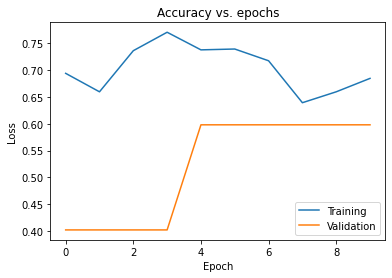

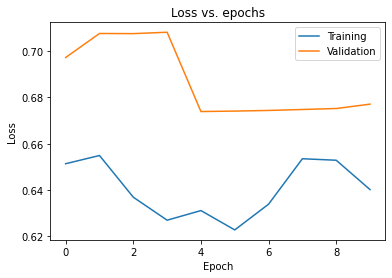

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 